Q1:
parametric models:
Linear regression
Neural network
Logistic regression

non-parametric models:
k nearest neighbour

Q2:细细切作臊子

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Q2(1)
def sign(num):
    if num > 0:
        print(1)
    else:
        print(-1)
w=np.array([1,-2,-1])
#这里没有x2，相当于w2是个偏置，所以令x2=1
x=np.array([3,0,1])
sign(np.dot(w,x))
x=np.array([1,1,1])
sign(np.dot(w,x))


1
-1


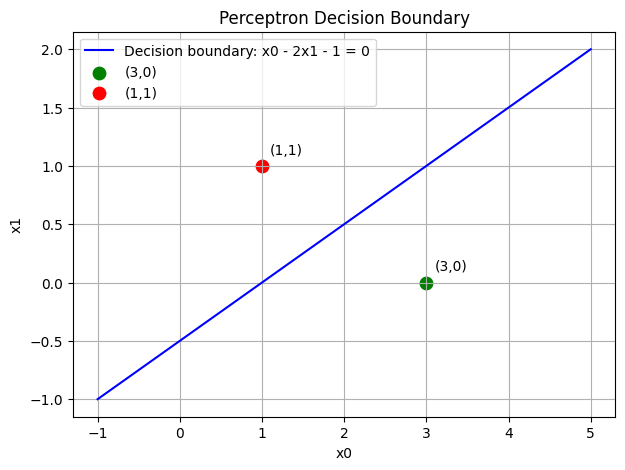

In [5]:
#Q2(2)
x0_vals = np.linspace(-1, 5, 200)
x1_vals = (x0_vals - 1) / 2

plt.figure(figsize=(7,5))
# 决策边界满足：
# w0*x0 + w1*x1 + w2 = 0
# 1*x0 + (-2)*x1 + (-1) = 0
# x0 - 2*x1 - 1 = 0
plt.plot(x0_vals, x1_vals, label='Decision boundary: x0 - 2x1 - 1 = 0', color='blue')

plt.scatter(3, 0, color='green', s=80, label='(3,0)')
plt.scatter(1, 1, color='red', s=80, label='(1,1)')

plt.text(3.1, 0.1, '(3,0)')
plt.text(1.1, 1.1, '(1,1)')

plt.xlabel('x0')
plt.ylabel('x1')
plt.title('Perceptron Decision Boundary')
plt.grid(True)
plt.legend()
plt.show()


In [6]:
# Q2(3）Yes, the parameters should be updated.
# HOW TO UPDATE:
# learning rate
alpha = 1
w = np.array([1, -2])
x = np.array([3, 0])
true_y = -1
w0, w1 = w+alpha*np.dot(true_y, x)
print("Updated parameters:", w0, w1)

Updated parameters: -2 -2


Q3:
(1):
y and y_hat range in (0,1)

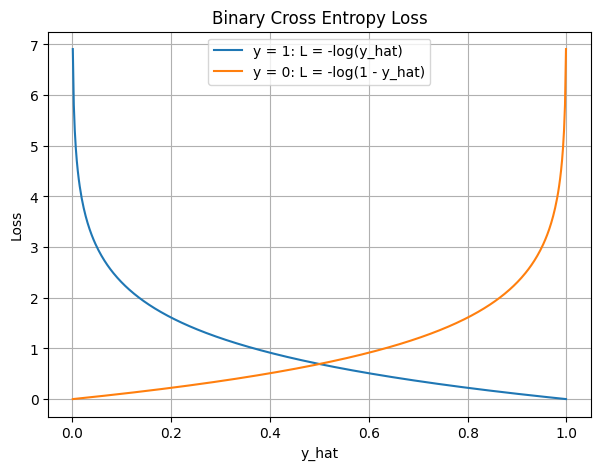

In [7]:
#Q3(2)
y_hat = np.linspace(0.001, 0.999, 500)

loss_y1 = -np.log(y_hat)          # y = 1
loss_y0 = -np.log(1 - y_hat)      # y = 0

plt.figure(figsize=(7,5))
plt.plot(y_hat, loss_y1, label='y = 1: L = -log(y_hat)')
plt.plot(y_hat, loss_y0, label='y = 0: L = -log(1 - y_hat)')

plt.xlabel('y_hat')
plt.ylabel('Loss')
plt.title('Binary Cross Entropy Loss')
plt.grid(True)
plt.legend()
plt.show()

/var/folders/3s/0f7yy_w17rx6hg9jqjnll71c0000gn/T/ipykernel_8450/4045046340.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


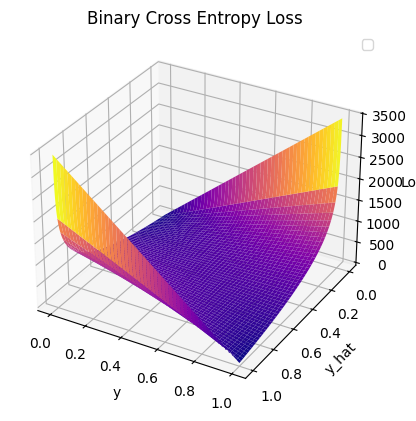

<Figure size 700x500 with 0 Axes>

In [25]:
#Q3(3)(4)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

y_hat = np.linspace(0.001, 0.999, 500)
y = np.linspace(0.001, 0.999, 500)
y,y_hat=np.meshgrid(y,y_hat)
loss = -np.log(y_hat).dot(y)-np.log(1 - y_hat).dot(1 - y)         


plt.figure(figsize=(7,5))
ax.plot_surface(y,y_hat,loss, cmap='plasma')
ax.set_ylabel('y_hat')
ax.set_xlabel("y")
ax.set_zlabel('Loss')

ax.set_title('Binary Cross Entropy Loss')
ax.grid(True)
ax.legend()
ax.invert_yaxis()
plt.show()


Q3（3）（4）
如图所示，
当y=y_hat时候函数值处于低谷，函数对y_hat求导结果是(y_hat-y)/[y_hat*(1-y_hat)],当y=y_hat的时候导数为0，说明这个时候取到极值，结合图像来看是确实是极小值，最小值。
当y和y_hat差距较大的时候，loss的值变得特别大


Q4

In [ ]:
#Q4（1）（2）(3)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
y = y == 1   # transform to binary classification

In [49]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
y_pred=knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy:", accuracy)


Test set accuracy: 1.0


In [51]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy:", accuracy)

Test set accuracy: 0.8


可见knn表现更好

In [ ]:
#Q4(4)
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

X, y = load_iris(return_X_y=True)
y = y == 1

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

print("KNN")
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print("\nLogistic Regression")
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))


KNN
Precision: 1.0
Recall: 1.0
F1: 1.0

Logistic Regression
Precision: 0.7142857142857143
Recall: 0.5555555555555556
F1: 0.625


In [2]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
y = y == 1 
x_train_val, x_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.25, random_state=42,stratify=y_train_val
)
from sklearn.neighbors import KNeighborsClassifier
param_grid = {"n_neighbors": list(range(1, 16))}
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(x_train, y_train)

best_k = grid.best_params_["n_neighbors"]
print("Best k:", best_k)
print("Best CV accuracy:", grid.best_score_)

# 5) evaluate on validation set
val_pred = grid.best_estimator_.predict(x_val)
val_acc = accuracy_score(y_val, val_pred)
print("Validation accuracy:", val_acc)

# 6) retrain on train+val using best k, then evaluate on test set
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train_val, y_train_val)

test_pred = final_model.predict(x_test)
test_acc = accuracy_score(y_test, test_pred)
print("Test accuracy:", test_acc)

Best k: 2
Best CV accuracy: 0.9555555555555555
Validation accuracy: 0.9666666666666667
Test accuracy: 1.0
